In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import random

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

random.seed(42)
np.random.seed(42)

In [2]:
companies = pd.read_csv("companies.csv")
portfolio_edges = pd.read_csv("portfolio_edges.csv")
feature_matrix = pd.read_csv("feature_matrix.csv")
edu_job_features = pd.read_csv("edu_job_features.csv")

print("companies:", companies.shape)
print("portfolio_edges:", portfolio_edges.shape)
print("feature_matrix:", feature_matrix.shape)
print("edu_job_features:", edu_job_features.shape)

companies: (6704, 22)
portfolio_edges: (461543, 6)
feature_matrix: (6704, 37)
edu_job_features: (6704, 15)


In [3]:
companies = companies[companies["is_success"].notna()].copy()
companies["is_success"] = companies["is_success"].astype(int)

feature_matrix = feature_matrix[feature_matrix["is_success"].notna()].copy()
feature_matrix["is_success"] = feature_matrix["is_success"].astype(int)

print("Labeled companies:", companies.shape)
print("Labeled feature_matrix:", feature_matrix.shape)
print("Positive rate:", feature_matrix["is_success"].mean())

Labeled companies: (6593, 22)
Labeled feature_matrix: (6593, 37)
Positive rate: 0.16927043834369787


In [4]:
G = nx.Graph()

for _, row in portfolio_edges.iterrows():
    investor_id = "inv_" + str(row["vc_uuid"])
    company_id = str(row["portfolio_company_uuid"])
    G.add_edge(investor_id, company_id)

print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())

Graph nodes: 160243
Graph edges: 353034


In [5]:
def random_walk(graph, start_node, walk_length=20):
    walk = [start_node]
    for _ in range(walk_length - 1):
        current = walk[-1]
        neighbors = list(graph.neighbors(current))
        if not neighbors:
            break
        walk.append(random.choice(neighbors))
    return [str(x) for x in walk]


def generate_walks(graph, num_walks=10, walk_length=20, seed=42):
    random.seed(seed)
    nodes = list(graph.nodes())
    walks = []
    for _ in range(num_walks):
        random.shuffle(nodes)
        for node in nodes:
            walks.append(random_walk(graph, node, walk_length))
    return walks


walks = generate_walks(G, num_walks=10, walk_length=20, seed=42)
print("Number of walks:", len(walks))
print("Example walk:", walks[0][:10])

Number of walks: 1602430
Example walk: ['0c6c101e-53f6-49c9-a57c-7f98a08301e4', 'inv_796e4250-e66a-1c7b-6ccf-5a4fbd3b1936', 'f08a3bfa-32a0-0015-645c-d893f2a2c2ae', 'inv_9183d3fb-c801-bc11-1594-04850e47cf60', 'ca9a4738-54ec-435a-95c9-1faabdf24b7d', 'inv_73633ee4-ea65-2967-6c5d-9b5fec7d2d5e', '9dc9cd36-acc4-43e0-96e9-b57eff2dbbed', 'inv_73633ee4-ea65-2967-6c5d-9b5fec7d2d5e', '73c10c11-d3e8-4c87-8378-14d959b3e7e1', 'inv_73633ee4-ea65-2967-6c5d-9b5fec7d2d5e']


In [6]:
embedding_model = Word2Vec(
    sentences=walks,
    vector_size=64,
    window=8,
    min_count=0,
    sg=1,
    workers=1,
    epochs=5,
    negative=10,
    seed=42
)

print("Embedding dimension:", embedding_model.vector_size)
print("Vocabulary size:", len(embedding_model.wv))

Embedding dimension: 64
Vocabulary size: 160243


In [7]:
embedding_dict = {}

company_ids = feature_matrix["company_uuid"].astype(str).unique()

for company_id in company_ids:
    if company_id in embedding_model.wv:
        embedding_dict[company_id] = embedding_model.wv[company_id]
    else:
        embedding_dict[company_id] = np.zeros(embedding_model.vector_size)

emb_df = pd.DataFrame.from_dict(embedding_dict, orient="index")
emb_df.index.name = "company_uuid"
emb_df.reset_index(inplace=True)
emb_df.columns = ["company_uuid"] + [f"emb_{i}" for i in range(emb_df.shape[1] - 1)]

print("emb_df shape:", emb_df.shape)
emb_df.head()

emb_df shape: (6593, 65)


,company_uuid,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63
0,fdd4bfe1-5f7b-e403-d100-91e9ec01f903,-0.108929,-0.995046,0.531705,-0.281332,-0.289924,-0.225257,0.056728,-0.392882,-0.150768,...,-1.006673,0.114113,0.792177,-0.350311,0.590157,-0.187191,-0.156340,0.065064,0.239592,0.893593
1,1ebaa59b-7035-75d2-316d-e7b35b8a82ed,0.145004,-0.518885,0.569358,-0.450374,-0.832039,0.056461,-0.637699,-0.692186,-0.300682,...,-1.451867,-0.140173,0.096407,-0.629707,0.461866,0.153900,0.579108,0.796369,-0.033158,0.744794
2,4361b5e3-697b-325f-63e7-1814d63b865f,-0.284019,-0.120201,-0.480805,-0.262499,-0.435268,0.138014,0.133393,-0.674461,-0.428321,...,-1.049135,-0.165571,-0.049453,-0.347720,0.286726,-0.579591,-0.004968,0.525606,0.789777,0.513938
3,5e298e78-0999-fe40-4b90-c21ed1c90786,-0.051471,-0.063093,0.373351,-0.664593,-0.068097,0.019844,-0.283134,0.803357,-0.818693,...,0.146655,0.007719,0.233660,0.004892,0.385854,-0.582060,-1.014730,-0.203855,0.769196,0.685743
4,16c38a41-e42c-e440-f372-d5f382be7662,0.397779,-0.321748,0.074575,0.002683,-0.313032,0.321360,-0.383782,-0.545824,0.101816,...,-1.149326,0.583931,-0.376966,0.143758,0.561721,-0.105478,0.011120,-0.566657,1.155717,-0.356170


In [8]:
leakage_cols = [
    "funding_total_usd",
    "log_funding",
    "num_funding_rounds",
    "company_age_months"
]

drop_cols = ["is_success"] + [col for col in leakage_cols if col in feature_matrix.columns]

feature_only_df = feature_matrix.drop(columns=drop_cols).copy()

for col in feature_only_df.columns:
    if feature_only_df[col].dtype == bool:
        feature_only_df[col] = feature_only_df[col].astype(int)

print("feature_only_df shape:", feature_only_df.shape)

feature_only_df shape: (6593, 32)


In [9]:
edu_job_df = edu_job_features.copy()

for col in edu_job_df.columns:
    if edu_job_df[col].dtype == bool:
        edu_job_df[col] = edu_job_df[col].astype(int)

edu_job_df = edu_job_df.fillna(0)

print("edu_job_df shape:", edu_job_df.shape)

edu_job_df shape: (6704, 15)


In [10]:
base_df = feature_matrix[["company_uuid", "is_success"]].copy()

v1_df = base_df.merge(feature_only_df, on="company_uuid", how="left")
v1_df = v1_df.merge(emb_df, on="company_uuid", how="left")
v1_df = v1_df.fillna(0)

v2_df = v1_df.merge(edu_job_df, on="company_uuid", how="left")
v2_df = v2_df.fillna(0)

print("v1_df:", v1_df.shape)
print("v2_df:", v2_df.shape)

v1_df: (6593, 97)
v2_df: (6593, 111)


In [11]:
def evaluate_xgb_classification(model_df, model_name="Model"):
    X = model_df.drop(columns=["company_uuid", "is_success"]).copy()
    y = model_df["is_success"].astype(int).copy()

    X.columns = X.columns.astype(str)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = neg / pos if pos > 0 else 1.0

    clf = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        clf, X, y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    clf.fit(X_train, y_train)

    y_pred_prob = clf.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_prob >= 0.5).astype(int)

    roc_auc = roc_auc_score(y_test, y_pred_prob)
    pr_auc = average_precision_score(y_test, y_pred_prob)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)

    print(f"\n===== {model_name} =====")
    print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Test ROC-AUC: {roc_auc:.4f}")
    print(f"Test PR-AUC: {pr_auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Success Precision: {precision:.4f}")
    print(f"Success Recall: {recall:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Not Success", "Success"]))

    return {
        "model_name": model_name,
        "clf": clf,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred_prob": y_pred_prob,
        "y_pred": y_pred,
        "cv_roc_auc_mean": cv_scores.mean(),
        "cv_roc_auc_std": cv_scores.std(),
        "test_roc_auc": roc_auc,
        "test_pr_auc": pr_auc,
        "accuracy": accuracy,
        "success_precision": precision,
        "success_recall": recall
    }

In [12]:
result_v1 = evaluate_xgb_classification(v1_df, model_name="V1: Network + Node2Vec + XGBoost")
result_v2 = evaluate_xgb_classification(v2_df, model_name="V2: + Edu/Job Features")


===== V1: Network + Node2Vec + XGBoost =====
CV ROC-AUC: 0.8376 ± 0.0119
Test ROC-AUC: 0.8217
Test PR-AUC: 0.5664
Accuracy: 0.8218
Success Precision: 0.4783
Success Recall: 0.5919
              precision    recall  f1-score   support

 Not Success       0.91      0.87      0.89      1096
     Success       0.48      0.59      0.53       223

    accuracy                           0.82      1319
   macro avg       0.70      0.73      0.71      1319
weighted avg       0.84      0.82      0.83      1319


===== V2: + Edu/Job Features =====
CV ROC-AUC: 0.8348 ± 0.0119
Test ROC-AUC: 0.8253
Test PR-AUC: 0.5628
Accuracy: 0.8135
Success Precision: 0.4591
Success Recall: 0.5785
              precision    recall  f1-score   support

 Not Success       0.91      0.86      0.88      1096
     Success       0.46      0.58      0.51       223

    accuracy                           0.81      1319
   macro avg       0.68      0.72      0.70      1319
weighted avg       0.83      0.81      0.82      

In [13]:
compare_df = pd.DataFrame({
    "Metric": [
        "CV ROC-AUC",
        "Test ROC-AUC",
        "Test PR-AUC",
        "Accuracy",
        "Success Precision",
        "Success Recall"
    ],
    "V1 (Network)": [
        result_v1["cv_roc_auc_mean"],
        result_v1["test_roc_auc"],
        result_v1["test_pr_auc"],
        result_v1["accuracy"],
        result_v1["success_precision"],
        result_v1["success_recall"]
    ],
    "V2 (+Edu/Job)": [
        result_v2["cv_roc_auc_mean"],
        result_v2["test_roc_auc"],
        result_v2["test_pr_auc"],
        result_v2["accuracy"],
        result_v2["success_precision"],
        result_v2["success_recall"]
    ]
})

compare_df["Delta"] = compare_df["V2 (+Edu/Job)"] - compare_df["V1 (Network)"]
compare_df["Improved?"] = compare_df["Delta"].apply(lambda x: "↑" if x > 0 else ("↓" if x < 0 else "="))

compare_df

,Metric,V1 (Network),V2 (+Edu/Job),Delta,Improved?
0,CV ROC-AUC,0.837568,0.834847,-0.002722,↓
1,Test ROC-AUC,0.821673,0.825345,0.003672,↑
2,Test PR-AUC,0.566394,0.562768,-0.003626,↓
3,Accuracy,0.821835,0.813495,-0.008340,↓
4,Success Precision,0.478261,0.459075,-0.019186,↓
5,Success Recall,0.591928,0.578475,-0.013453,↓


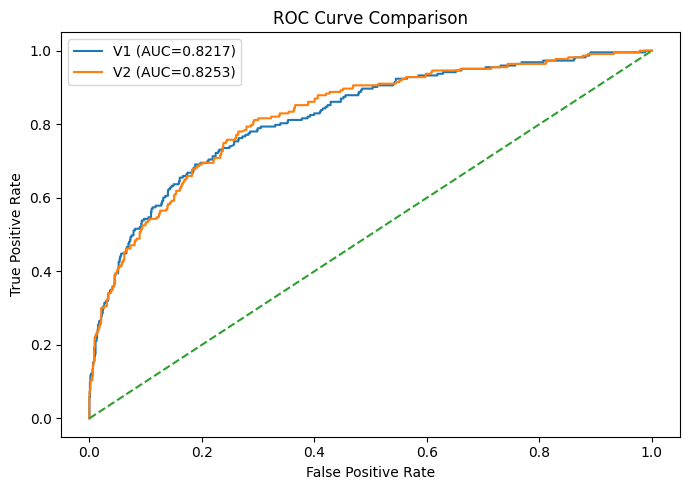

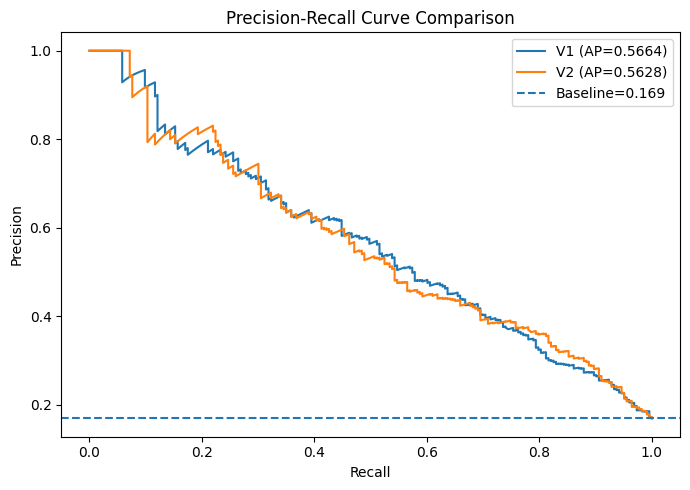

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# ROC
fpr1, tpr1, _ = roc_curve(result_v1["y_test"], result_v1["y_pred_prob"])
fpr2, tpr2, _ = roc_curve(result_v2["y_test"], result_v2["y_pred_prob"])

plt.figure(figsize=(7, 5))
plt.plot(fpr1, tpr1, label=f'V1 (AUC={result_v1["test_roc_auc"]:.4f})')
plt.plot(fpr2, tpr2, label=f'V2 (AUC={result_v2["test_roc_auc"]:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# PR
precision1, recall1, _ = precision_recall_curve(result_v1["y_test"], result_v1["y_pred_prob"])
precision2, recall2, _ = precision_recall_curve(result_v2["y_test"], result_v2["y_pred_prob"])

baseline = result_v1["y_test"].mean()

plt.figure(figsize=(7, 5))
plt.plot(recall1, precision1, label=f'V1 (AP={result_v1["test_pr_auc"]:.4f})')
plt.plot(recall2, precision2, label=f'V2 (AP={result_v2["test_pr_auc"]:.4f})')
plt.axhline(y=baseline, linestyle='--', label=f'Baseline={baseline:.3f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd
import numpy as np
import networkx as nx
import random

from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from xgboost import XGBClassifier

random.seed(42)
np.random.seed(42)

investor_nodes = [n for n in G.nodes() if str(n).startswith("inv_")]
company_nodes_graph = [n for n in G.nodes() if not str(n).startswith("inv_")]

positive_edges = []
for u, v in G.edges():
    if str(u).startswith("inv_") and not str(v).startswith("inv_"):
        positive_edges.append((str(u), str(v)))
    elif str(v).startswith("inv_") and not str(u).startswith("inv_"):
        positive_edges.append((str(v), str(u)))

positive_edges = list(set(positive_edges))

print("Total positive edges:", len(positive_edges))

train_pos_edges, test_pos_edges = train_test_split(
    positive_edges,
    test_size=0.2,
    random_state=42
)

print("Train positive edges:", len(train_pos_edges))
print("Test positive edges:", len(test_pos_edges))

G_train_link = nx.Graph()
G_train_link.add_nodes_from([str(n) for n in investor_nodes + company_nodes_graph])
G_train_link.add_edges_from(train_pos_edges)

print("Train link graph nodes:", G_train_link.number_of_nodes())
print("Train link graph edges:", G_train_link.number_of_edges())

def random_walk(graph, start_node, walk_length=15):
    walk = [start_node]
    for _ in range(walk_length - 1):
        cur = walk[-1]
        neighbors = list(graph.neighbors(cur))
        if not neighbors:
            break
        walk.append(random.choice(neighbors))
    return [str(x) for x in walk]

def generate_walks(graph, num_walks=5, walk_length=15, seed=42):
    random.seed(seed)
    nodes = list(graph.nodes())
    walks = []
    for _ in range(num_walks):
        random.shuffle(nodes)
        for node in nodes:
            if graph.degree(node) > 0:
                walks.append(random_walk(graph, node, walk_length))
    return walks

walks_train_link = generate_walks(G_train_link, num_walks=5, walk_length=15, seed=42)
print("Number of train walks:", len(walks_train_link))

embedding_dim = 64

embedding_model_link = Word2Vec(
    sentences=walks_train_link,
    vector_size=embedding_dim,
    window=8,
    min_count=0,
    sg=1,
    workers=8,
    epochs=5,
    negative=10,
    seed=42
)

print("Link embedding trained.")

def sample_negative_edges_excluding(
    existing_edges_set,
    investor_nodes,
    company_nodes,
    n_samples,
    used_negatives=None,
    seed=42
):
    random.seed(seed)
    negatives = set()
    if used_negatives is None:
        used_negatives = set()

    while len(negatives) < n_samples:
        inv = str(random.choice(investor_nodes))
        comp = str(random.choice(company_nodes))
        edge = (inv, comp)

        if edge in existing_edges_set:
            continue
        if edge in used_negatives:
            continue

        negatives.add(edge)

    return list(negatives)

all_positive_set = set(positive_edges)

train_neg_edges = sample_negative_edges_excluding(
    existing_edges_set=all_positive_set,
    investor_nodes=investor_nodes,
    company_nodes=company_nodes_graph,
    n_samples=len(train_pos_edges),
    used_negatives=None,
    seed=42
)

test_neg_edges = sample_negative_edges_excluding(
    existing_edges_set=all_positive_set,
    investor_nodes=investor_nodes,
    company_nodes=company_nodes_graph,
    n_samples=len(test_pos_edges),
    used_negatives=set(train_neg_edges),
    seed=43
)

print("Train negative edges:", len(train_neg_edges))
print("Test negative edges:", len(test_neg_edges))

Total positive edges: 353034
Train positive edges: 282427
Test positive edges: 70607
Train link graph nodes: 160243
Train link graph edges: 282427
Number of train walks: 708425
Link embedding trained.
Train negative edges: 282427
Test negative edges: 70607


In [22]:
def get_node_embedding(node, embedding_model, dim=64):
    node = str(node)
    if node in embedding_model.wv:
        return embedding_model.wv[node]
    return np.zeros(dim)

def build_edge_features(edge_list, label, embedding_model, dim=64):
    rows = []
    for inv, comp in edge_list:
        emb_inv = get_node_embedding(inv, embedding_model, dim)
        emb_comp = get_node_embedding(comp, embedding_model, dim)

        # Hadamard product
        hadamard = emb_inv * emb_comp

        row = {
            "investor_id": inv,
            "company_id": comp,
            "label": label
        }
        for i in range(dim):
            row[f"edge_emb_{i}"] = hadamard[i]

        rows.append(row)

    return pd.DataFrame(rows)

train_pos_df = build_edge_features(train_pos_edges, 1, embedding_model_link, dim=embedding_dim)
train_neg_df = build_edge_features(train_neg_edges, 0, embedding_model_link, dim=embedding_dim)
test_pos_df  = build_edge_features(test_pos_edges, 1, embedding_model_link, dim=embedding_dim)
test_neg_df  = build_edge_features(test_neg_edges, 0, embedding_model_link, dim=embedding_dim)

train_link_df = pd.concat([train_pos_df, train_neg_df], axis=0).reset_index(drop=True)
test_link_df  = pd.concat([test_pos_df, test_neg_df], axis=0).reset_index(drop=True)

print("train_link_df shape:", train_link_df.shape)
print("test_link_df shape:", test_link_df.shape)

train_link_df shape: (564854, 67)
test_link_df shape: (141214, 67)


In [23]:
X_train_link = train_link_df.drop(columns=["investor_id", "company_id", "label"]).copy()
y_train_link = train_link_df["label"].astype(int).copy()

X_test_link = test_link_df.drop(columns=["investor_id", "company_id", "label"]).copy()
y_test_link = test_link_df["label"].astype(int).copy()

clf_link = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=8
)

clf_link.fit(X_train_link, y_train_link)

y_link_prob = clf_link.predict_proba(X_test_link)[:, 1]
y_link_pred = (y_link_prob >= 0.5).astype(int)

print("Leakage-free Link Prediction ROC-AUC:", roc_auc_score(y_test_link, y_link_prob))
print("Leakage-free Link Prediction PR-AUC:", average_precision_score(y_test_link, y_link_prob))
print(classification_report(y_test_link, y_link_pred, target_names=["No Link", "Link"]))

Leakage-free Link Prediction ROC-AUC: 0.6579628528589537
Leakage-free Link Prediction PR-AUC: 0.7488529019617263
              precision    recall  f1-score   support

     No Link       0.57      0.98      0.72     70607
        Link       0.93      0.27      0.42     70607

    accuracy                           0.63    141214
   macro avg       0.75      0.63      0.57    141214
weighted avg       0.75      0.63      0.57    141214



In [35]:
def rank_candidate_vcs_for_startup(
    startup_uuid,
    investor_nodes,
    embedding_model,
    clf_link,
    graph_train,
    top_k=10,
    dim=64,
    exclude_existing=True
):
    startup_uuid = str(startup_uuid)

    rows = []
    existing_investors = set()

    if exclude_existing and startup_uuid in graph_train:
        existing_investors = {
            str(n) for n in graph_train.neighbors(startup_uuid)
            if str(n).startswith("inv_")
        }

    emb_comp = get_node_embedding(startup_uuid, embedding_model, dim)

    for inv in investor_nodes:
        inv = str(inv)

        if exclude_existing and inv in existing_investors:
            continue

        emb_inv = get_node_embedding(inv, embedding_model, dim)
        hadamard = emb_inv * emb_comp

        row = {f"edge_emb_{i}": hadamard[i] for i in range(dim)}
        rows.append((inv, row))

    score_df = pd.DataFrame([r[1] for r in rows])
    probs = clf_link.predict_proba(score_df)[:, 1]

    out = pd.DataFrame({
        "investor_id": [r[0] for r in rows],
        "predicted_link_score": probs
    }).sort_values("predicted_link_score", ascending=False).head(top_k)

    return out

 # example
example_startup = str(feature_matrix["company_uuid"].iloc[0])

top_vcs = rank_candidate_vcs_for_startup(
    startup_uuid=example_startup,
    investor_nodes=investor_nodes,
    embedding_model=embedding_model_link,
    clf_link=clf_link,
    graph_train=G_train_link,
    top_k=10,
    dim=64,
    exclude_existing=True
)

top_vcs

,investor_id,predicted_link_score
7734,inv_6976989c-3c27-b212-5b60-54b5652aa15f,0.952295
8483,inv_2ef4fe0f-8850-49cb-8304-e5d93aacd164,0.933333
7568,inv_229ca413-fc96-49ba-9425-3e50c3842a24,0.929391
4847,inv_9a9b8b44-1c59-19f0-3138-ccb89d13b0b4,0.912292
2556,inv_07ac3525-a55a-0525-472a-d6fae1fb0a37,0.911495
7197,inv_b2b2129d-97d8-41ad-29c3-06ef390edf8d,0.907923
7260,inv_14b91224-d0aa-4089-a095-fae749f12df9,0.901153
8534,inv_a70bd1bb-8d91-4fb6-9742-c6b0901e971e,0.881692
7828,inv_0c0f3174-3571-4e18-a8c0-b37686da83a8,0.879886
6938,inv_006211f2-7254-4586-3a0b-effd696cce1b,0.878209


In [29]:
import numpy as np
import pandas as pd
import networkx as nx
from itertools import combinations

investor_nodes = [n for n in G.nodes() if str(n).startswith("inv_")]

G_inv = nx.Graph()
G_inv.add_nodes_from(investor_nodes)

for company in [n for n in G.nodes() if not str(n).startswith("inv_")]:
    inv_neighbors = [n for n in G.neighbors(company) if str(n).startswith("inv_")]
    if len(inv_neighbors) >= 2:
        for u, v in combinations(inv_neighbors, 2):
            if G_inv.has_edge(u, v):
                G_inv[u][v]["weight"] += 1
            else:
                G_inv.add_edge(u, v, weight=1)

print("Investor projection nodes:", G_inv.number_of_nodes())
print("Investor projection edges:", G_inv.number_of_edges())

pagerank_inv = nx.pagerank(G_inv, weight="weight")
degree_centrality_inv = nx.degree_centrality(G_inv)

ranking_inv_df = pd.DataFrame({
    "node": list(G_inv.nodes()),
    "pagerank": [pagerank_inv[n] for n in G_inv.nodes()],
    "degree_centrality": [degree_centrality_inv[n] for n in G_inv.nodes()]
})

for col in ["pagerank", "degree_centrality"]:
    ranking_inv_df[col + "_log"] = np.log1p(ranking_inv_df[col])
    min_v = ranking_inv_df[col + "_log"].min()
    max_v = ranking_inv_df[col + "_log"].max()
    ranking_inv_df[col + "_norm"] = (ranking_inv_df[col + "_log"] - min_v) / (max_v - min_v + 1e-12)

ranking_inv_df["connector_score"] = (
    0.7 * ranking_inv_df["pagerank_norm"] +
    0.3 * ranking_inv_df["degree_centrality_norm"]
)

ranking_inv_df = ranking_inv_df.sort_values("connector_score", ascending=False)
ranking_inv_df.head(20)

Investor projection nodes: 8560
Investor projection edges: 433889


,node,pagerank,degree_centrality,pagerank_log,pagerank_norm,degree_centrality_log,degree_centrality_norm,connector_score
59,inv_73633ee4-ea65-2967-6c5d-9b5fec7d2d5e,0.010243,0.364529,0.010191,1.000000,0.310809,0.952360,0.985708
70,inv_e8487396-f60c-25f1-2bb5-bfcb4e0f4b66,0.006477,0.385910,0.006456,0.632866,0.326357,1.000000,0.743006
1,inv_3718597a-dd39-6661-3630-09cdd43bcac2,0.006602,0.324454,0.006580,0.645067,0.281000,0.861022,0.709853
260,inv_56e40f50-97c7-2a77-255d-1d97d5f30646,0.004257,0.258558,0.004248,0.415787,0.229967,0.704649,0.502446
518,inv_1bd15aa6-56ac-0d89-9405-7b7a4c8f76f0,0.004199,0.259259,0.004191,0.410165,0.230524,0.706355,0.499022
259,inv_089e2f4e-5b16-b5ef-8834-3a40302de5ac,0.003847,0.282743,0.003839,0.375658,0.249001,0.762972,0.491852
135,inv_902deab4-ec41-68ce-d9df-c0c959578176,0.004294,0.202126,0.004285,0.419431,0.184092,0.564082,0.462826
168,inv_ce91bad7-b6d8-e56e-0f45-4763c6c5ca29,0.003861,0.232387,0.003854,0.377079,0.208953,0.640259,0.456033
127,inv_93c87ab7-7cee-5c54-9941-104693dbbdba,0.003359,0.264050,0.003353,0.327863,0.234320,0.717989,0.444901
521,inv_0c867fde-2b9a-df10-fdb9-66b74f355f91,0.003270,0.219769,0.003264,0.319131,0.198661,0.608724,0.406009


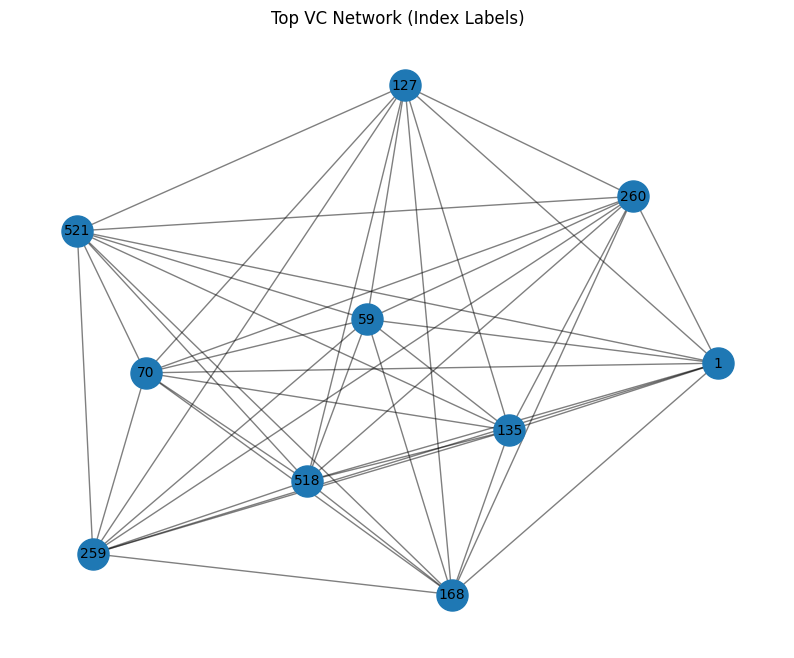

In [34]:
import matplotlib.pyplot as plt
top_df = ranking_inv_df.head(10)
top_vcs = top_df["node"].tolist()
label_map = {row["node"]: idx for idx, row in top_df.iterrows()}

G_sub = G_inv.subgraph(top_vcs)
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_sub, seed=42)
nx.draw_networkx_nodes(G_sub, pos, node_size=500)
nx.draw_networkx_edges(G_sub, pos, alpha=0.5)

nx.draw_networkx_labels(G_sub, pos, labels=label_map, font_size=10)
plt.title("Top VC Network (Index Labels)")
plt.axis("off")
plt.show()